In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.io import ascii
import seaborn as sns
from spectral_cube import SpectralCube
from scipy.optimize import curve_fit

FWHM_const = 2 * np.sqrt(2 * np.log(2))
nu11 = 23.6944955e9

size_convert = 1 # Conversion factor derived from comparing (crossmatching) ClumpFind outputs from RAMPS with RAMPS catalog
linewidth_convert = 1

In [10]:
Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_bl.fits') # Bring in spectral cube to obtain longitude, latitude, and V_LSR values from pixel values

hdr = Cube.header
x_channel_width = abs(hdr['CDELT1']) # Pixel size in degrees (channel width of x axis, longitude)
# y_channel_width = hdr['CDELT2']
v_channel_width = hdr['CDELT3'] # Channel width (Hz) (channel width of v axis, velocity)

def expFunc(x, a, b):
    return a * np.power(x, b)

In [11]:
hdul = fits.open("/home/scratch/hfwest/Pilot/Results_ClumpFind/Pilot_cat.FIT")
pilot_table = Table(hdul[1].data)
pilot_table['Linear Size (pc)'] = np.zeros(len(pilot_table))
pilot_table['sigma (km/s)'] = np.zeros(len(pilot_table))
pilot_table['Size1'] *= size_convert
pilot_table['Size2'] *= size_convert
for row in pilot_table:
    row['Linear Size (pc)'] = max(row['Size1'], row['Size2']) * x_channel_width * 7000 # Assumed distance to midpoint cloud: 7 kpc --> now in pc
    row['sigma (km/s)'] = row['Size3'] * v_channel_width * linewidth_convert * (3e8 / nu11) 
pilot_table

PIDENT,Peak1,Peak2,Peak3,Cen1,Cen2,Cen3,Size1,Size2,Size3,Sum,Peak,Volume,Linear Size (pc),sigma (km/s)
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,5.5,49.5,194.5,7.933658297048007,50.415367465840255,195.41384828591364,2.2594442881051413,1.0571076061116993,3.0609544805164672,23.823580389719773,1.9924327868930036,105.0,39.540275041839976,2217.2934109616403
2,178.5,59.5,193.5,175.9651409082528,60.53056021329634,194.7291379779926,3.7255110771545716,2.8274122033996516,3.6522260128374167,974.8668894991031,1.6176305723032434,2122.0,65.196443850205,2645.5985298548912
3,5.5,67.5,187.5,13.478960186269061,61.364861543291376,180.7417435502492,4.234729481180678,5.693777091689724,5.851632678585421,127.31449153195702,1.5285319010174343,1017.0,99.64109910457017,4238.804158696952
4,81.5,81.5,167.5,84.80593947322423,78.48698896880632,169.73025900519153,6.1556258567627795,4.756168619406617,4.161613220911687,2715.2826812017674,1.5137749714504212,8736.0,107.72345249334865,3014.5883032345514
5,6.5,19.5,134.5,7.558825070266719,18.89043443914948,134.53761565002765,0.8413232366470196,1.44309686832855,1.0476986527154233,22.373517983714283,1.4292264006456121,64.0,25.254195195749627,758.9316777253522
6,164.5,49.5,201.5,162.4877725427074,51.06731920553781,201.29652883088318,5.127071915628704,3.374090071307581,4.947814487355816,1167.030287139429,1.4119234086414716,2167.0,89.72375852350233,3584.0965722638025
7,5.5,80.5,182.5,11.082697601540037,81.64648408356807,185.44160185527227,3.580044794934465,2.0263301215808704,2.8666736681942298,57.00364032442307,1.4103681997414577,336.0,62.65078391135314,2076.560326631132
8,116.5,40.5,197.5,115.99796402141834,37.759694699039265,198.40934502994097,5.571119432261525,5.164735336784966,5.395532757185083,1812.5130266943718,1.3553769175248795,8236.0,97.49459006457668,3908.4146161871736
9,5.5,82.5,197.5,8.674053530946848,82.56502931254165,195.8436466493674,3.8148077162315435,2.260866118638388,3.529165315900217,52.493766688923664,1.352951714112742,309.0,66.75913503405201,2556.455854194729


In [12]:
ramps_table = ascii.read('/users/hfwest/GBO-REU/Data/RAMPS_cleaned.csv')
ramps_table

l,b,Linear Size (pc),sigma (km/s)
float64,float64,float64,float64
9.612,0.142,2.3864112030245943,0.314694522311
9.623,0.191,5.3133799197117835,0.83105567403
9.629,0.266,1.1929340623080675,0.333130734574
9.634,0.298,0.7400928202292074,0.224414712996
9.649,-0.017,1.8243493536347024,0.319746510224
9.662,0.264,2.586392766502899,0.330921630441
9.69,-0.003,1.487332862537587,0.428652790448
9.698,-0.111,5.5215555638074925,0.650161586359
9.701,-0.224,3.832945962848816,0.549691520273


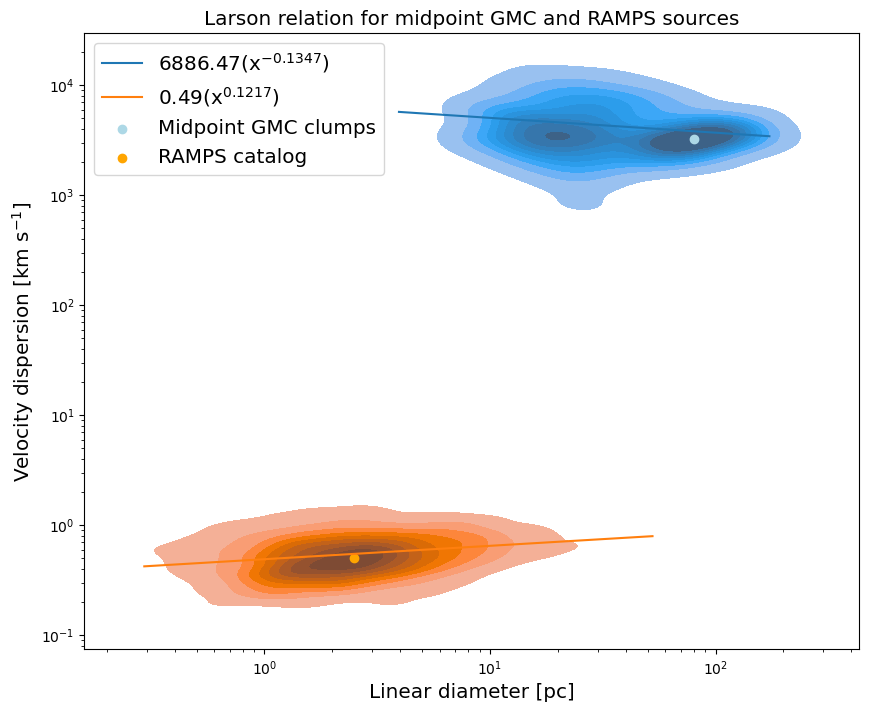

In [17]:
plt.figure(figsize= (10, 8))

plt.loglog()

sns.kdeplot(x = pilot_table['Linear Size (pc)'], y = pilot_table['sigma (km/s)'], fill= True)
sns.kdeplot(x = ramps_table['Linear Size (pc)'], y = ramps_table['sigma (km/s)'], fill= True)

pilotopt, pilotcov = curve_fit(expFunc, pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'])
rampsopt, rampscov = curve_fit(expFunc, ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'])

plt.plot([min(pilot_table['Linear Size (pc)']), max(pilot_table['Linear Size (pc)'])], [expFunc(min(pilot_table['Linear Size (pc)']), *pilotopt), expFunc(max(pilot_table['Linear Size (pc)']), *pilotopt)], label= '%.2f(x$^{%.4f}$)' % tuple(pilotopt))
plt.plot([min(ramps_table['Linear Size (pc)']), max(ramps_table['Linear Size (pc)'])], [expFunc(min(ramps_table['Linear Size (pc)']), *rampsopt), expFunc(max(ramps_table['Linear Size (pc)']), *rampsopt)], label= '%.2f(x$^{%.4f}$)' % tuple(rampsopt))

plt.scatter(80, 3.25e3, color = 'lightblue', label = 'Midpoint GMC clumps')
plt.scatter(2.5, .5, color = 'orange', label = 'RAMPS catalog')

plt.title('Larson relation for midpoint GMC and RAMPS sources', fontsize= 'x-large')
plt.legend(fontsize = 'x-large')
plt.xlabel('Linear diameter [pc]', fontsize = 'x-large')
plt.ylabel('Velocity dispersion [km s$^{-1}$]', fontsize = 'x-large')

plt.show()